## Tidal Decomposition 

The goal of this notebook is do low pass filter velocity data so we can remove the effects of tides. We will subtract the low-pass filtered velocity data from the in-situ data to get the high frequency component that will have the tidal signals in it. Note if we want to truly isolate tides we should do a harmonic analysis or bandpass filter to more specifically target tidal frequencies. For now, we will just do a low-pass filter. However, these considerations will become important if I want to estimate tidal kinetic energy 

In [1]:
# imports 
import numpy as np 
import matplotlib.pyplot as plt
import xarray as xr 
import scipy 
import TNB_tools.tides.tidal_decomposition as tides
import TNB_tools.tides.tidal_hydro_relationships as tidal_hydro 

In [2]:
# load in data - DELL 
vel = xr.open_dataset("//thepenguin/penguin2/Data/TNB/mooring/LDEO/2018_19 Araon Cruise (ANA09B) - NIWAMooringRetrieval/Data/TNBD/working/tnbd_2018_vel_bot_1093.nc") 

In [3]:
# load in CTD data 
ctd = xr.open_dataset("//thepenguin/penguin2/Data/TNB/mooring/LDEO/2018_19 Araon Cruise (ANA09B) - NIWAMooringRetrieval/Data/TNBD/working/tnbd_2018_ctd_bot_1093.nc")

In [4]:
ctd_15 = ctd.resample(time='15min').mean()

In [8]:
# select time range to match with velocity data 
ctd_15 = ctd_15.sel(time=slice('2018-03-14','2018-12-31'))

In [9]:
# select time range to match with CTD data
vel = vel.sel(time=slice('2018-03-14','2018-12-31'))

In [4]:
sampling_hours = 0.25  # sampling period (hrs)
window_days = 3     # desired window 
window_size = int(window_days * 24 / sampling_hours)   # window size based on sampling period 


In [5]:
window_size

288

In [6]:
if window_size % 2 == 0:
    window_size += 1

In [7]:
from scipy.signal import windows
import numpy as np

cosine_window = windows.cosine(window_size)
cosine_window /= cosine_window.sum()  # normalize so it acts like a moving average


In [8]:
len(cosine_window)

289

In [16]:
sampling_hours = 0.25  # sampling period (hrs)
window_days = 1     # desired window 
window_size = int(window_days * 24 / sampling_hours) 

if window_size % 2 == 0:
    window_size += 1

cosine_window = windows.cosine(window_size)
cosine_window /= cosine_window.sum()  # normalize so it acts like a moving average

# assume velocity_da is your DataArray with dimension "time"
cosine_weights = xr.DataArray(cosine_window, dims="window")

# create rolling window and apply weights
tnbd_east_filtered = (
    vel.u
    .rolling(time=window_size, center=True)
    .construct("window")
    .dot(cosine_weights)
)

tnbd_north_filtered = (
    vel.v
    .rolling(time=window_size, center=True)
    .construct("window")
    .dot(cosine_weights)
)


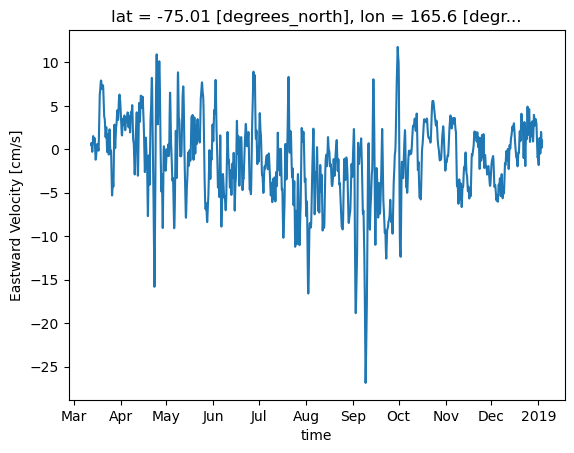

In [17]:
tnbd_east_filtered.plot()

In [18]:
# subtract low-pass from in-situ 
tides_zonal = vel.u - tnbd_east_filtered
tides_meridional = vel.v - tnbd_north_filtered

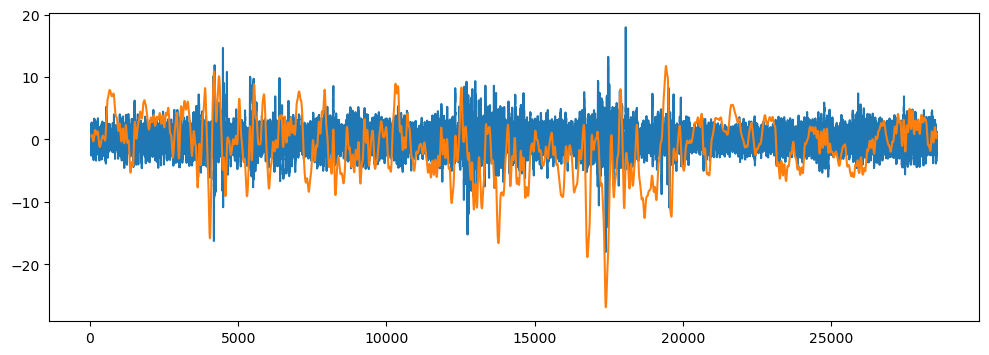

In [27]:
fig = plt.figure(figsize=(12,4))
plt.plot(tnbd_east_tidal)
plt.plot(tnbd_east_filtered)

In [24]:
# using functions 
lowpass_ds, highpass_ds = tides.decompose_tidal_dataset(
    vel, var_names=["u", "v"], window_days=1, sampling_hours=0.25
)

tnbd_east_filtered = lowpass_ds["u"]
tnbd_east_tidal = highpass_ds["u"]

In [25]:
lowpass_ds

<xarray.Dataset> Size: 687kB
Dimensions:  (time: 28610)
Coordinates:
  * time     (time) datetime64[ns] 229kB 2018-03-12 ... 2019-01-03T23:59:54
    lat      float64 8B -75.01
    lon      float64 8B 165.6
    z        int64 8B 1093
Data variables:
    u        (time) float64 229kB nan nan nan nan nan ... nan nan nan nan nan
    v        (time) float64 229kB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    decomposition:  low-pass via cosine window, window_days=1, sampling_hours...

In [26]:
highpass_ds

<xarray.Dataset> Size: 687kB
Dimensions:  (time: 28610)
Coordinates:
  * time     (time) datetime64[ns] 229kB 2018-03-12 ... 2019-01-03T23:59:54
    lat      float64 8B -75.01
    lon      float64 8B 165.6
    z        int64 8B 1093
Data variables:
    u        (time) float64 229kB nan nan nan nan nan ... nan nan nan nan nan
    v        (time) float64 229kB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    decomposition:  high-pass residual via cosine window, window_days=1, samp...

### Tides w hydrographic signals 

In [11]:
_, u_hp = tides.decompose_tidal(vel.u, window_days=1, sampling_hours=0.25)
_, v_hp = tides.decompose_tidal(vel.v, window_days=1, sampling_hours=0.25)

In [12]:
tke_envelope = tidal_hydro.tidal_energy_envelope(u_hp, v_hp,window_days=14.8,sampling_hours=0.25)

In [13]:
s_lowpass, s_anomaly = tidal_hydro.lowpass_and_anomaly(ctd_15.abs_sal,window_days=14.8,sampling_hours=0.25)

In [14]:
lags, corr, n_eff, conf95 = tidal_hydro.lagged_cross_correlation(tke_envelope, s_anomaly, max_lag=60)

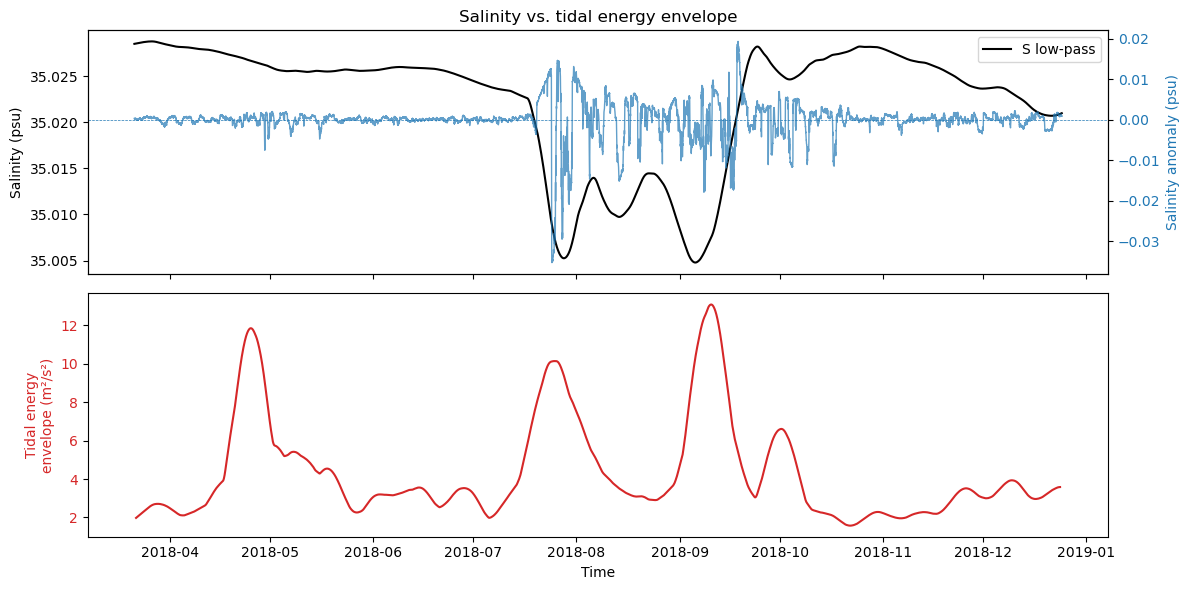

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Salinity: low-pass state and anomaly
axes[0].plot(s_lowpass.time, s_lowpass, color="k", lw=1.5, label="S low-pass")
# axes[0].axhline(0, color="gray", lw=0.5)
axes[0].set_ylabel("Salinity (psu)")
axes[0].legend(loc="upper right")

ax0b = axes[0].twinx()
ax0b.plot(s_anomaly.time, s_anomaly, color="tab:blue", lw=1, alpha=0.7, label="S anomaly")
ax0b.axhline(0, color="tab:blue", lw=0.5, ls="--")
ax0b.set_ylabel("Salinity anomaly (psu)", color="tab:blue")
ax0b.tick_params(axis="y", labelcolor="tab:blue")

# Tidal energy envelope
axes[1].plot(tke_envelope.time, tke_envelope, color="tab:red", lw=1.5)
axes[1].set_ylabel("Tidal energy\nenvelope (m²/s²)", color="tab:red")
axes[1].tick_params(axis="y", labelcolor="tab:red")
axes[1].set_xlabel("Time")

axes[0].set_title("Salinity vs. tidal energy envelope")
fig.tight_layout()
plt.show()

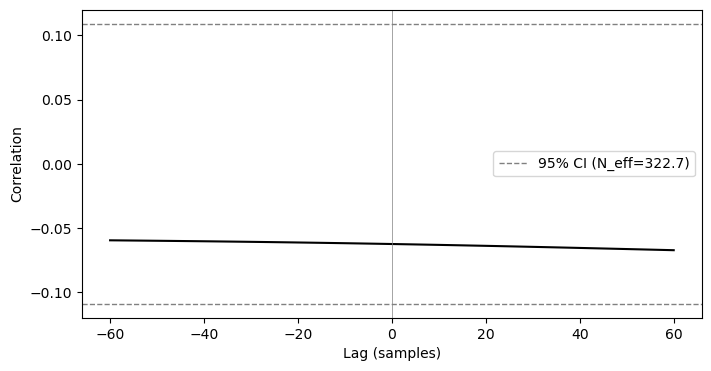

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lags, corr, color="k")
ax.axhline(conf95, color="gray", ls="--", lw=1, label=f"95% CI (N_eff={n_eff:.1f})")
ax.axhline(-conf95, color="gray", ls="--", lw=1)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("Lag (samples)")
ax.set_ylabel("Correlation")
ax.legend()
plt.show()